# Indian Government Schemes — Exploratory Data Analysis

## GitHub Dataset

### Objective

Analyze the GitHub government schemes dataset to understand its structure,
data quality, eligibility information, scheme coverage, textual information,
and suitability for building an agentic AI system for government scheme
discovery and assistance.

1. Dataset Overview
2. Import Libraries
3. Load Dataset
4. Basic Dataset Inspection
5. Schema and Data Types
6. Missing Value Analysis
7. Duplicate Analysis
8. Unique Value and Cardinality Analysis
9. Categorical Feature Analysis
10. Geographic / State-wise Analysis
11. Scheme Category Analysis
12. Beneficiary Analysis
13. Eligibility Analysis
14. Eligibility Information Quality Analysis
15. Text/Data Quality Analysis
16. URL and Source Analysis
17. Cross-Field Consistency Analysis
18. Final Assessment of the GitHub Dataset

## 1. Dataset Overview

### Overview

This section provides an initial overview of the GitHub Government Schemes
dataset, including its size, structure, available features, and a sample of
the records.

The objective is to understand the dataset before performing detailed
analysis of data quality, eligibility information, categorical distributions,
text fields, and its suitability for the proposed agentic AI system.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

In [2]:
df = pd.read_csv("/content/gov_myscheme_data.csv")

In [4]:
df.shape

(2066, 16)

In [5]:
df.head()

,Scheme Name,Scheme Slug,Level,State / UT / Ministry,Application Mode,Tags / Categories,Description,Eligibility Criteria,Eligibility (General),Exclusions / Ineligibility,Benefits,Application Process,Documents Required,Frequently Asked Questions (FAQs),Official Link,MyScheme URL
0,25% Capital Investment Subsidy Scheme,25-ciss,State / UT Government,Lakshadweep,Offline,"Capital, Investment, Subsidy, Entrepreneur, Unemployed, Youth","Introduction: The Union Territory of Lakshadweep has been declared as the ""No industrial Area"" a...","Any individual above 18 years of age including Women, ex-servicemen & physically handicapped is ...","Any individual above 18 years of age including Women, ex-servicemen & physically handicapped is ...",The entrepreneurs who enjoyed any other subsidy from any other Institutions such as Lakshadweep ...,"Under the scheme, financial assistance of 25 % of the total cost of the Enterprise inclusive of ...",Mode: OfflineStep 01: The Scheme will be advertised/ published through the Panchayat Raj Institu...,• Photocopy of the Aadhaar CardCaste certificateBank account detailsCertificate of physically\n•...,"Q: What is the ""25% Capital Investment Subsidy Scheme""?\nA: The Union Territory of Lakshadweep h...",https://www.myscheme.gov.in/schemes/25-ciss,https://www.myscheme.gov.in/schemes/25-ciss
1,"40% Subsidy On Hank Yarn, Dyes & Chemicals Scheme",40shydcs,State / UT Government,Andhra Pradesh,Offline,"Subsidy, Hank, Yarn, Dyes, Chemicals, Handloom, Weaver","The ""40% subsidy on Hank Yarn, Dyes & Chemicals Scheme"" is a Subsidy Scheme by the Department of...","The subsidy will be available only on purchase / procurement of yarn from NHDC, Yarn Deports san...","The subsidy will be available only on purchase / procurement of yarn from NHDC, Yarn Deports san...","The Weavers Cooperative Societies shall not claim any subsidy on the Yarn, Dyes and Chemicals pu...","40% subsidy on the purchases / procurements of Hank Yarn, Dyes & Chemicals from NHDC & APCO.The ...",Mode: Offline Application:Step 1: The claims for subsidy shall be submitted by the Weavers Coope...,• Certification that subsidy has been claimed only on the Hank Yarn and Dyes & Chemicals supplie...,Q: Which Department Manages This Scheme?\nA: This scheme is managed by the Department of Handloo...,https://www.aphandtex.gov.in/open_record.php?ID=136Where,https://www.myscheme.gov.in/schemes/40shydcs
2,AICTE - Grant For Augmenting Infrastructure In North Eastern Region,a-gainer,Central Government,Ministry of Education,Offline,"AICTE, Grant, For, Augmenting, Infrastructure, North, Eastern, Region",Introductiona. The scheme (operated hitherto as Special Scheme for NER) provides financial assis...,a. Government/ Government-aided technical/ engineering colleges/University Departments including...,a. Government/ Government-aided technical/ engineering colleges/University Departments including...,NaN,The selected institutes will have to complete the sanctioned project as per the following guidel...,Mode: OfflineStep 1: Download and fill out the application form for AICTE-Grant for Augmenting I...,• Essential Documents Required with Application Form:(To Solve Water Problem in general)a. Plan/...,Q: Why Are Water Harvesting Projects Supported Under The Scheme?\nA: North East India largely ha...,https://www.myscheme.gov.in/schemes/a-gainer,https://www.myscheme.gov.in/schemes/a-gainer
3,ARAVANAIPPU,a-pudu,State / UT Government,Puducherry,Offline,"Child, Financial, Assistance, Girl, Mother, Nutrition","The scheme ""ARAVANAIPPU"" is a financial assistance scheme by the Department of Women and Child D...",The applicant should be a citizen of India. The applicant should be a native of Puducherry by vi...,The applicant should be a citizen of India. The applicant should be a native of Puducherry by vi...,NaN,₹1200 financial assistance to lactating mothers.*The selection is periodical and depends on the ...,Mode: OfflineStep 1: The interested applicant should visit (during

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2066 entries, 0 to 2065
Data columns (total 16 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Scheme Name                        2066 non-null   object
 1   Scheme Slug                        2066 non-null   object
 2   Level                              2066 non-null   object
 3   State / UT / Ministry              2066 non-null   object
 4   Application Mode                   2066 non-null   object
 5   Tags / Categories                  2050 non-null   object
 6   Description                        2066 non-null   object
 7   Eligibility Criteria               2065 non-null   object
 8   Eligibility (General)              2064 non-null   object
 9   Exclusions / Ineligibility         379 non-null    object
 10  Benefits                           2066 non-null   object
 11  Application Process                2066 non-null   object
 12  Docume

In [7]:
df.columns.tolist()

['Scheme Name',
 'Scheme Slug',
 'Level',
 'State / UT / Ministry',
 'Application Mode',
 'Tags / Categories',
 'Description',
 'Eligibility Criteria',
 'Eligibility (General)',
 'Exclusions / Ineligibility',
 'Benefits',
 'Application Process',
 'Documents Required',
 'Frequently Asked Questions (FAQs)',
 'Official Link',
 'MyScheme URL']

In [8]:
missing_count = df.isnull().sum()

missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
}).sort_values("Missing Count", ascending=False)

missing_summary

,Missing Count,Missing Percentage
Exclusions / Ineligibility,1687,81.655373
Tags / Categories,16,0.774443
Documents Required,4,0.193611
Eligibility (General),2,0.096805
Eligibility Criteria,1,0.048403
State / UT / Ministry,0,0.000000
Scheme Name,0,0.000000
Scheme Slug,0,0.000000
Description,0,0.000000
Application Mode,0,0.000000


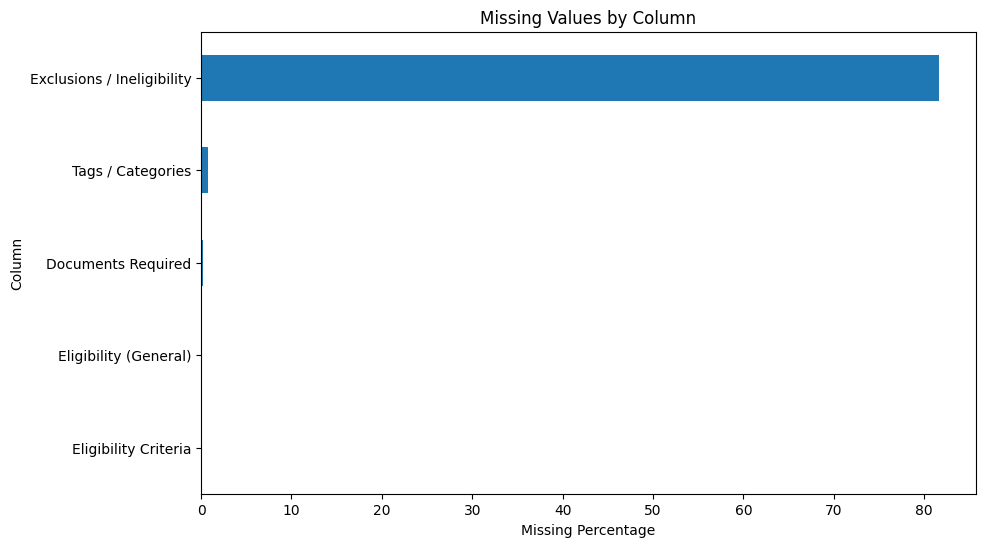

In [9]:
plt.figure(figsize=(10, 6))

missing_percentage[missing_percentage > 0].sort_values().plot(
    kind="barh"
)

plt.xlabel("Missing Percentage")
plt.ylabel("Column")
plt.title("Missing Values by Column")

plt.show()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["Scheme Slug"].duplicated().sum()


np.int64(0)

In [12]:
df["Scheme Name"].duplicated().sum()

np.int64(0)

In [13]:
id_columns = ["Scheme Slug", "Scheme Name"]

content_columns = [
    "Description",
    "Eligibility Criteria",
    "Eligibility (General)",
    "Benefits",
    "Application Process"
]

for col in content_columns:
    print(f"{col}: {df[col].duplicated().sum()} duplicate values")

Description: 8 duplicate values
Eligibility Criteria: 41 duplicate values
Eligibility (General): 44 duplicate values
Benefits: 55 duplicate values
Application Process: 397 duplicate values


In [14]:
df.nunique().sort_values()

,0
Level,2
Application Mode,4
State / UT / Ministry,80
Exclusions / Ineligibility,344
Official Link,1543
Application Process,1669
Documents Required,2000
Benefits,2011
Tags / Categories,2021
Eligibility (General),2021


In [15]:
df["Level"].value_counts()

,count
Level,
State / UT Government,1539
Central Government,527


In [16]:
df["Application Mode"].value_counts()

,count
Application Mode,
Online,914
Offline,868
Online & Offline,277
Direct / Not Specified,7


In [17]:
df["State / UT / Ministry"].value_counts()

,count
State / UT / Ministry,
Puducherry,186
Gujarat,118
Goa,116
Tamil Nadu,108
Ministry of Social Justice and Empowerment,85
...,...
"Ministry of Consumer Affairs, Food and Public Distribution",1
Ministry of Railways,1
Ministry of Food Processing Industries,1


In [40]:
df["Tags / Categories"].value_counts().head(20)

,count
Tags / Categories,
"Agriculture, Farmer, Farming",5
"Financial, Assistance, Higher, Education, Student, Finance",4
"Empowerment, Financial, Assistance, Social, Welfare",3
"Building, Worker, Construction, Death, Financial, Assistance, Funeral, Labour",3
"Building, Worker, Construction, Labour, Pension",3
"Education, Financial, Assistance, Scholarship, Skill, Development, Student",2
"Development, Farmer, Farming",2
"Building, Worker, Construction, Financial, Assistance, Labour, Maternity, Pregnancy, Woman",2
"Maniammaiyar, Ninaivu, Marriage, Assistance, Daughter, Poor, Widows, Financial, Widow",2


In [19]:
df.groupby("Level")["State / UT / Ministry"].nunique()

,State / UT / Ministry
Level,
Central Government,45
State / UT Government,35


In [20]:
state_df = df[df["Level"] == "State / UT Government"]

state_df["State / UT / Ministry"].value_counts()

,count
State / UT / Ministry,
Puducherry,186
Gujarat,118
Goa,116
Tamil Nadu,108
Rajasthan,83
Kerala,72
Chhattisgarh,64
Meghalaya,63
Madhya Pradesh,62


In [21]:
tag_count = (
    df["Tags / Categories"]
    .fillna("")
    .apply(lambda x: len([tag.strip() for tag in x.split(",") if tag.strip()]))
)

tag_count.describe()

,Tags / Categories
count,2066.000000
mean,9.283156
std,4.387046
min,0.000000
25%,6.000000
50%,9.000000
75%,12.000000
max,30.000000


In [22]:
individual_tags = (
    df["Tags / Categories"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

individual_tags.value_counts().head(30)

,count
Tags / Categories,
Assistance,780
Financial,766
Ministry,398
Student,285
Welfare,277
For,258
Social,249
Education,220
And,218


In [23]:
beneficiary_keywords = [
    "Student", "Students", "Farmer", "Farmers",
    "Women", "Woman", "Child", "Children",
    "Youth", "Worker", "Labour", "Senior",
    "Elderly", "Disability", "Disabled",
    "Widow", "Widows", "SC", "ST",
    "Scheduled", "Minority", "Entrepreneur"
]

beneficiary_tag_counts = {
    keyword: individual_tags[
        individual_tags.str.lower() == keyword.lower()
    ].shape[0]
    for keyword in beneficiary_keywords
}

pd.Series(beneficiary_tag_counts).sort_values(ascending=False)

,0
Student,285
Worker,159
Scheduled,148
Disability,141
Students,131
Labour,126
Farmer,122
Women,100
Farmers,81
Widow,68


In [24]:
eligibility_columns = [
    "Eligibility Criteria",
    "Eligibility (General)",
    "Exclusions / Ineligibility"
]

df[eligibility_columns].notna().sum()

,0
Eligibility Criteria,2065
Eligibility (General),2064
Exclusions / Ineligibility,379


In [25]:
(
    df["Eligibility Criteria"].fillna("")
    == df["Eligibility (General)"].fillna("")
).sum()

np.int64(1665)

In [26]:
for col in eligibility_columns:
    lengths = df[col].fillna("").str.len()

    print(f"\n{col}")
    print(lengths.describe())


Eligibility Criteria
count    2066.000000
mean      829.251210
std       915.487809
min         0.000000
25%       301.000000
50%       543.500000
75%      1022.750000
max      9333.000000
Name: Eligibility Criteria, dtype: float64

Eligibility (General)
count    2066.000000
mean      748.194579
std       815.110989
min         0.000000
25%       281.000000
50%       503.000000
75%       912.000000
max      9197.000000
Name: Eligibility (General), dtype: float64

Exclusions / Ineligibility
count    2066.000000
mean       75.408519
std       287.501653
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      5723.000000
Name: Exclusions / Ineligibility, dtype: float64


In [27]:
eligibility_text = (
    df["Eligibility Criteria"].fillna("") + " " +
    df["Eligibility (General)"].fillna("")
).str.lower()

eligibility_keywords = {
    "age": r"\bage\b|\byears?\b",
    "income": r"\bincome\b|\bsalary\b",
    "gender": r"\bmale\b|\bfemale\b|\bwoman\b|\bwomen\b|\bman\b",
    "caste": r"\bsc\b|\bst\b|\bobc\b|\bcaste\b|\bscheduled caste\b|\bscheduled tribe\b",
    "residence": r"\bresident\b|\bresidence\b|\bdomicile\b",
    "disability": r"\bdisab",
    "occupation": r"\bfarm(er|ing)?\b|\bstudent\b|\bworker\b|\blabou?r\b|\bemploy",
    "citizenship": r"\bcitizen\b|\bcitizenship\b|\bindian\b"
}

keyword_counts = {
    category: eligibility_text.str.contains(pattern, regex=True, na=False).sum()
    for category, pattern in eligibility_keywords.items()
}

pd.Series(keyword_counts).sort_values(ascending=False)

,0
age,1170
occupation,820
residence,682
income,525
caste,357
gender,291
citizenship,286
disability,212


In [28]:
for col in ["Eligibility Criteria", "Eligibility (General)"]:
    lengths = df[col].fillna("").str.strip().str.len()

    print(f"\n{col}")
    print("Empty:", (lengths == 0).sum())
    print("Very short (<50 chars):", (lengths < 50).sum())
    print("Short (<100 chars):", (lengths < 100).sum())


Eligibility Criteria
Empty: 1
Very short (<50 chars): 18
Short (<100 chars): 76

Eligibility (General)
Empty: 2
Very short (<50 chars): 19
Short (<100 chars): 88


In [29]:
description_lengths = df["Description"].fillna("").str.strip().str.len()

description_lengths.describe()

,Description
count,2066.000000
mean,888.752662
std,791.934507
min,19.000000
25%,432.000000
50%,638.000000
75%,1058.750000
max,8649.000000


In [30]:
benefits_lengths = df["Benefits"].fillna("").str.strip().str.len()

benefits_lengths.describe()

,Benefits
count,2066.000000
mean,682.513553
std,928.719791
min,8.000000
25%,174.000000
50%,382.500000
75%,834.750000
max,16838.000000


In [31]:
application_lengths = df["Application Process"].fillna("").str.strip().str.len()

application_lengths.describe()

,Application Process
count,2066.000000
mean,1159.964666
std,887.023254
min,12.000000
25%,591.000000
50%,953.500000
75%,1478.500000
max,11250.000000


In [32]:
documents_lengths = df["Documents Required"].fillna("").str.strip().str.len()

documents_lengths.describe()

,Documents Required
count,2066.000000
mean,479.899806
std,537.849825
min,0.000000
25%,177.000000
50%,326.000000
75%,595.750000
max,8111.000000


In [33]:
faq_lengths = df["Frequently Asked Questions (FAQs)"].fillna("").str.strip().str.len()

faq_lengths.describe()

,Frequently Asked Questions (FAQs)
count,2066.000000
mean,2447.070668
std,1459.191038
min,85.000000
25%,1603.250000
50%,2216.000000
75%,3024.000000
max,23480.000000


In [34]:
(df["Official Link"] == df["MyScheme URL"]).sum()

np.int64(990)

In [35]:
df["Official Link"].value_counts().head(20)

,count
Official Link,
https://cglabour.nic.in,40
https://scholarships.gov.in/,31
https://suneethi.sjd.kerala.gov.in,24
https://esamajkalyan.gujarat.gov.in,20
https://awards.gov.in,18
http://www.scholarships.gov.in/,15
https://sainik.py.gov.in/,14
https://bocw.delhi.gov.in/,14
https://sso.rajasthan.gov.in/signin,14


In [36]:
url_columns = ["Official Link", "MyScheme URL"]

for col in url_columns:
    empty_count = df[col].fillna("").str.strip().eq("").sum()
    print(f"{col}: {empty_count} empty values")

Official Link: 0 empty values
MyScheme URL: 0 empty values


In [37]:
df[df["Level"] == "Central Government"]["State / UT / Ministry"].value_counts()

,count
State / UT / Ministry,
Ministry of Social Justice and Empowerment,85
Ministry of Education,69
Ministry of Science and Technology,57
Ministry of Agriculture and Farmers Welfare,49
"Ministry of Micro, Small and Medium Enterprises",29
Ministry of Commerce and Industry,27
Ministry of Finance,18
Ministry Of H,18
Ministry of Textiles,17


In [38]:
df[df["Level"] == "State / UT Government"]["State / UT / Ministry"].value_counts()

,count
State / UT / Ministry,
Puducherry,186
Gujarat,118
Goa,116
Tamil Nadu,108
Rajasthan,83
Kerala,72
Chhattisgarh,64
Meghalaya,63
Madhya Pradesh,62


In [39]:
df[["Scheme Name", "Scheme Slug"]].duplicated().sum()

np.int64(0)

## 18. Final Assessment of the GitHub Dataset

The GitHub Government Schemes dataset contains 2,066 schemes across 16 fields and provides strong coverage of the information required for an Agentic AI and RAG-based government scheme assistance system.

### Strengths

- 2,066 unique schemes with no exact duplicate rows.
- `Scheme Name` and `Scheme Slug` provide unique scheme-level identification.
- `Description`, `Benefits`, `Application Process`, `Eligibility Criteria`, and `Eligibility (General)` are highly populated and contain substantial textual information.
- `FAQs` are available for all schemes and contain rich question-answer-oriented information, making them particularly valuable for semantic retrieval.
- `Documents Required` provides useful application-related information.
- Eligibility information frequently contains age, occupation, residence, income, caste/category, gender, citizenship, and disability-related information.
- `Application Mode` provides structured information about online and offline application availability.
- `Tags / Categories` provide multi-label semantic signals related to beneficiaries, sectors, scheme purposes, and services.
- Both `Official Link` and `MyScheme URL` are completely populated.
- The dataset covers both Central Government and State/UT Government schemes.

### Data Quality Considerations

- `Exclusions / Ineligibility` is sparse, with information available for only a minority of schemes.
- `Eligibility Criteria` and `Eligibility (General)` are identical for many schemes but differ for a substantial subset, so both should be retained until feature engineering is performed.
- `Tags / Categories` contain multiple comma-separated tags and require normalization during feature engineering.
- Some tags contain generic terms or variations such as singular/plural forms.
- `State / UT / Ministry` combines different concepts: states/UTs for state-level schemes and ministries/institutions for central schemes.
- Some central ministry values appear truncated and should be investigated during data cleaning.
- `Official Link` contains repeated government portals and some URL formatting variations such as HTTP/HTTPS differences.
- The state-wise distribution is uneven, with some states/UTs having substantially more schemes than others.

### Suitability for the Agentic AI System

The dataset is highly suitable for the planned system because it contains both structured metadata and rich unstructured text.

The most valuable fields for semantic retrieval are:

- Scheme Name
- Description
- Benefits
- Eligibility Criteria
- Eligibility (General)
- Exclusions / Ineligibility
- Application Process
- Documents Required
- FAQs
- Tags / Categories

Structured metadata such as government level, state/UT, application mode, and normalized beneficiary/category information can later support filtering and routing.

### Conclusion

The GitHub dataset is suitable for integration into the Government Scheme Agentic AI pipeline.

No major rows need to be removed based on the EDA findings. The next stage should focus on comparing the GitHub dataset with the Hugging Face dataset, identifying overlapping and complementary information, and then designing a unified AI-ready schema before feature engineering.